# Testbed HQVAE — reconstrucción de MNIST con ruido mixto

Sandbox para *lanzar pruebas* de reconstrucción (denoising) con **HQVAE** (VAE híbrido cuántico-clásico) frente a un **ConvVAE** clásico, variando el circuito cuántico (feature map, ansatz, entrelazamiento, reps, nº de qubits) y el optimizador. Cada run guarda un **HTML autocontenido** en `results/`.

Base bibliográfica: expresibilidad y capacidad de entrelazamiento de PQCs (Sim, Johnson & Aspuru-Guzik 2019, reutilizando `../expressibility/qexpr.py`) y ruido mixto de 3 clases (paper *4-QBITS C-Q NN for mixed noise type ID*). El paper *DE-VQE* motiva el eje "elección de optimizador" (se ofrecen Adam/otros y, opcional, COBYLA/SPSA; **no** evolución diferencial).

## 0. Dependencias

Regenera `requirements.txt` (sin versiones fijadas) e instálalo en el entorno actual. No se crea ningún `.venv`.

## 1. Setup

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'expressibility')))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import hqvae_lib as hl

SEED = 44
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('device:', DEVICE)

device: cuda


## 2. Datos (300 train / 100 val / 100 test)

MNIST con ruido mixto (3 clases de mezcla por pares). Cada muestra devuelve `(imagen_ruidosa, imagen_limpia)`.

In [2]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.11.0+cu128
12.8
True
1


train/val/test: 300 100 100


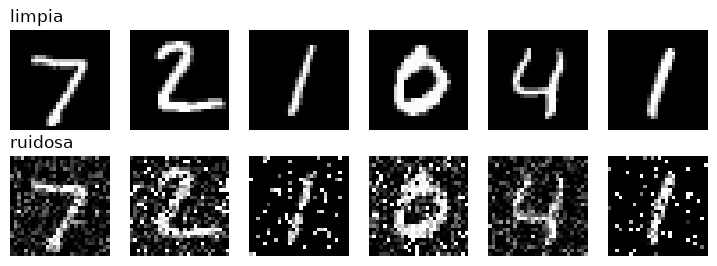

In [3]:
loaders = hl.load_denoising_mnist(n_train=300, n_val=100, n_test=100, batch_size=16, seed=SEED)
train_loader, val_loader, test_loader, test_ds = loaders
print('train/val/test:', len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

# vistazo a un lote (limpia vs ruidosa)
noisy, clean = next(iter(test_loader))
fig, axes = plt.subplots(2, 6, figsize=(9, 3))
for i in range(6):
    axes[0, i].imshow(clean[i].view(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(noisy[i].view(28, 28), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_title('limpia', loc='left'); axes[1, 0].set_title('ruidosa', loc='left')
plt.show()

## 3. Run único (editable)

Edita `cfg` para probar una configuración concreta. Prueba `n_qubits=4` o `6`. Con `epochs` bajos (p. ej. 5) es rápido para una primera prueba; súbelo (15) para resultados definitivos. Se entrena el HQVAE + un ConvVAE clásico baseline y se guarda un HTML comparativo.

In [4]:
cfg = hl.HQVAEConfig(
    n_qubits=6,                 # prueba 4 o 6
    feature_map='zz',           # 'zz' | 'pauli'
    ansatz='real_amplitudes',   # 'real_amplitudes' | 'efficient_su2'
    fm_entanglement='full',
    ansatz_entanglement='linear',
    reps=1,
    latent_dim=12,
    beta=0.5,
    epochs=15,                   # 15 para el resultado final
    lr=1e-3,
    optimizer='rmsprop',           # adam|adamw|sgd|rmsprop|lbfgs|cobyla|spsa
    seed=SEED,
)

out = hl.run_config(cfg, loaders, device=DEVICE, results_dir=RESULTS_DIR)
print('HTML:', out['html'])
pd.DataFrame([out['row']])

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE6_ZZFM_RA_linear_r1_rmsprop] entrenando HQVAE (rmsprop)...
  epoch  1/15  train=304.17  val=211.68
  epoch  2/15  train=219.95  val=207.89
  epoch  3/15  train=212.48  val=204.20
  epoch  4/15  train=210.31  val=201.24
  epoch  5/15  train=204.43  val=197.48
  epoch  6/15  train=197.96  val=190.32
  epoch  7/15  train=192.74  val=183.29
  epoch  8/15  train=183.11  val=176.74
  epoch  9/15  train=170.76  val=163.92
  epoch 10/15  train=164.20  val=157.10
  epoch 11/15  train=155.45  val=152.78
  epoch 12/15  train=149.42  val=147.61
  epoch 13/15  train=146.54  val=145.49
  epoch 14/15  train=142.73  val=142.79
  epoch 15/15  train=140.56  val=142.21
[HQVAE6_ZZFM_RA_linear_r1_rmsprop] entrenando ConvVAE baseline (adam)...
  epoch  1/15  train=417.65  val=267.94
  epoch  2/15  train=244.92  val=218.76
  epoch  3/15  train=218.76  val=209.35
  epoch  4/15  train=212.36  val=203.98
  epoch  5/15  train=206.09  val=198.69
  epoch  6/15  train=198.44  val=190.64
  epoch  7/15  train=1

,tag,n_qubits,feature_map,ansatz,entanglement,reps,optimizer,kl,Q,mse_hqvae,psnr_hqvae,ssim_hqvae,mse_vae,psnr_vae,ssim_vae
0,HQVAE6_ZZFM_RA_linear_r1_rmsprop,6,zz,real_amplitudes,linear,1,rmsprop,0.003817,0.948825,0.040753,14.237691,0.514396,0.035739,14.880469,0.566227


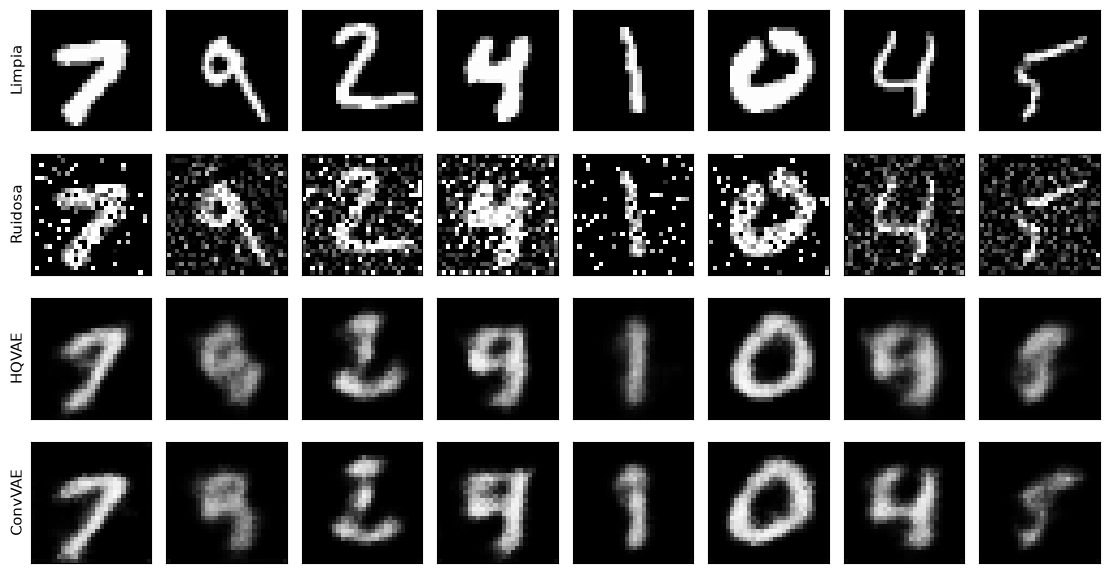

In [5]:
# reconstrucciones inline (Limpia / Ruidosa / HQVAE / ConvVAE)
_ = hl.fig_reconstruction_grid(out['hqvae'], out['vae'], test_ds, n=8, device=DEVICE)
plt.show()

## 4. Barrido (4 y 6 qubits, guiado por expresibilidad)

Recorre el grid definido en `hqvae_lib.default_sweep` (mezcla de 4 y 6 qubits, feature map × ansatz × entrelazamiento × reps). Genera un HTML por configuración y un CSV con métricas + descriptores KL (expresibilidad) y Q (Meyer-Wallach), para observar si mayor expresibilidad/entrelazamiento mejora PSNR/SSIM.

In [ ]:
sweep = hl.default_sweep(latent_dim=8, beta=0.5, epochs=15, seed=SEED)
print('configuraciones:', [c.tag() for c in sweep])

rows = []
for c in sweep:
    res = hl.run_config(c, loaders, device=DEVICE, results_dir=RESULTS_DIR, verbose=True)
    rows.append(res['row'])

df = pd.DataFrame(rows)
csv_path = os.path.join(RESULTS_DIR, 'sweep_metrics.csv')
df.to_csv(csv_path, index=False)
print('CSV ->', csv_path)
df

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


configuraciones: ['HQVAE6_ZZFM_RA_linear_r1', 'HQVAE4_ZZFM_RA_linear_r1', 'HQVAE6_ZZFM_RA_full_r1', 'HQVAE6_ZZFM_ESU2_linear_r1', 'HQVAE4_PFM_RA_linear_r1', 'HQVAE6_ZZFM_RA_linear_r2']
[HQVAE6_ZZFM_RA_linear_r1] entrenando HQVAE (adam)...
  epoch  1/15  train=440.93  val=292.20
  epoch  2/15  train=258.77  val=226.71
  epoch  3/15  train=224.51  val=210.86
  epoch  4/15  train=215.50  val=208.55
  epoch  5/15  train=211.88  val=203.14
  epoch  6/15  train=205.87  val=198.46
  epoch  7/15  train=200.67  val=193.55
  epoch  8/15  train=194.44  val=187.39
  epoch  9/15  train=188.42  val=183.26
  epoch 10/15  train=180.03  val=173.13
  epoch 11/15  train=171.04  val=163.62
  epoch 12/15  train=163.49  val=158.59
  epoch 13/15  train=156.52  val=154.06
  epoch 14/15  train=151.48  val=148.26
  epoch 15/15  train=146.29  val=146.18
[HQVAE6_ZZFM_RA_linear_r1] entrenando ConvVAE baseline (adam)...
  epoch  1/15  train=403.65  val=271.63
  epoch  2/15  train=247.28  val=223.57
  epoch  3/15  t

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE6_ZZFM_RA_linear_r1] HTML -> results\HQVAE6_ZZFM_RA_linear_r1.html
[HQVAE4_ZZFM_RA_linear_r1] entrenando HQVAE (adam)...
  epoch  1/15  train=412.53  val=267.89
  epoch  2/15  train=242.27  val=214.97
  epoch  3/15  train=216.73  val=206.88
  epoch  4/15  train=210.92  val=202.58
  epoch  5/15  train=207.64  val=202.95
  epoch  6/15  train=205.99  val=201.09
  epoch  7/15  train=202.69  val=196.75
  epoch  8/15  train=198.19  val=192.52
  epoch  9/15  train=192.66  val=185.91
  epoch 10/15  train=187.91  val=181.12
  epoch 11/15  train=180.24  val=174.46
  epoch 12/15  train=172.96  val=166.78
  epoch 13/15  train=167.79  val=160.86
  epoch 14/15  train=162.10  val=158.19
  epoch 15/15  train=158.82  val=154.14
[HQVAE4_ZZFM_RA_linear_r1] entrenando ConvVAE baseline (adam)...
  epoch  1/15  train=393.95  val=261.80
  epoch  2/15  train=244.47  val=220.29
  epoch  3/15  train=222.14  val=209.51
  epoch  4/15  train=212.62  val=202.81
  epoch  5/15  train=206.76  val=199.83
  epoch 

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


...

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE6_ZZFM_ESU2_linear_r1] HTML -> results\HQVAE6_ZZFM_ESU2_linear_r1.html
[HQVAE4_PFM_RA_linear_r1] entrenando HQVAE (adam)...
  epoch  1/15  train=404.57  val=261.46
  epoch  2/15  train=239.79  val=214.07
  epoch  3/15  train=216.00  val=206.47
  epoch  4/15  train=209.75  val=203.91
  epoch  5/15  train=206.45  val=198.46
  epoch  6/15  train=202.59  val=194.93
  epoch  7/15  train=206.30  val=194.75
  epoch  8/15  train=196.52  val=189.71
  epoch  9/15  train=191.81  val=184.51
  epoch 10/15  train=185.30  val=180.38
  epoch 11/15  train=180.57  val=175.35
  epoch 12/15  train=174.39  val=169.63
  epoch 13/15  train=172.38  val=165.75
  epoch 14/15  train=165.24  val=160.17
  epoch 15/15  train=162.93  val=158.93
[HQVAE4_PFM_RA_linear_r1] entrenando ConvVAE baseline (adam)...
  epoch  1/15  train=393.95  val=261.80
  epoch  2/15  train=244.47  val=220.29
  epoch  3/15  train=222.14  val=209.51
  epoch  4/15  train=212.62  val=202.81
  epoch  5/15  train=206.76  val=199.79
  epoc

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE4_PFM_RA_linear_r1] HTML -> results\HQVAE4_PFM_RA_linear_r1.html
[HQVAE6_ZZFM_RA_linear_r2] entrenando HQVAE (adam)...
  epoch  1/15  train=414.60  val=279.90
  epoch  2/15  train=252.36  val=222.43
  epoch  3/15  train=222.75  val=210.39
  epoch  4/15  train=214.48  val=205.84
  epoch  5/15  train=211.59  val=203.89
  epoch  6/15  train=209.07  val=202.21
  epoch  7/15  train=205.62  val=199.68
  epoch  8/15  train=202.80  val=196.19
  epoch  9/15  train=197.27  val=193.11
  epoch 10/15  train=193.18  val=184.44
  epoch 11/15  train=183.22  val=174.01
  epoch 12/15  train=173.43  val=165.07
  epoch 13/15  train=161.98  val=154.73
  epoch 14/15  train=154.48  val=150.60
  epoch 15/15  train=149.08  val=145.92
[HQVAE6_ZZFM_RA_linear_r2] entrenando ConvVAE baseline (adam)...
  epoch  1/15  train=394.67  val=262.55
  epoch  2/15  train=241.26  val=216.93
  epoch  3/15  train=218.66  val=207.28
  epoch  4/15  train=210.20  val=202.18
  epoch  5/15  train=203.43  val=192.48
  epoch  6

,tag,n_qubits,feature_map,ansatz,entanglement,reps,optimizer,kl,Q,mse_hqvae,psnr_hqvae,ssim_hqvae,mse_vae,psnr_vae,ssim_vae
0,HQVAE6_ZZFM_RA_linear_r1,6,zz,real_amplitudes,linear,1,adam,0.003817,0.948825,0.042294,14.060199,0.503226,0.041246,14.206422,0.517935
1,HQVAE4_ZZFM_RA_linear_r1,4,zz,real_amplitudes,linear,1,adam,0.009425,0.834302,0.045941,13.671868,0.432620,0.039169,14.440937,0.527605
2,HQVAE6_ZZFM_RA_full_r1,6,zz,real_amplitudes,full,1,adam,0.003571,0.949582,0.042779,14.002815,0.502239,0.041182,14.215120,0.518728
3,HQVAE6_ZZFM_ESU2_linear_r1,6,zz,efficient_su2,linear,1,adam,0.001763,0.945544,0.044751,13.753767,0.437827,0.039428,14.403075,0.537307
4,HQVAE4_PFM_RA_linear_r1,4,pauli,real_amplitudes,linear,1,adam,0.036015,0.629475,0.047284,13.517889,0.420528,0.039034,14.458555,0.530008
5,HQVAE6_ZZFM_RA_linear_r2,6,zz,real_amplitudes,linear,2,adam,0.001673,0.945670,0.042661,14.016398,0.478004,0.039325,14.486939,0.531553


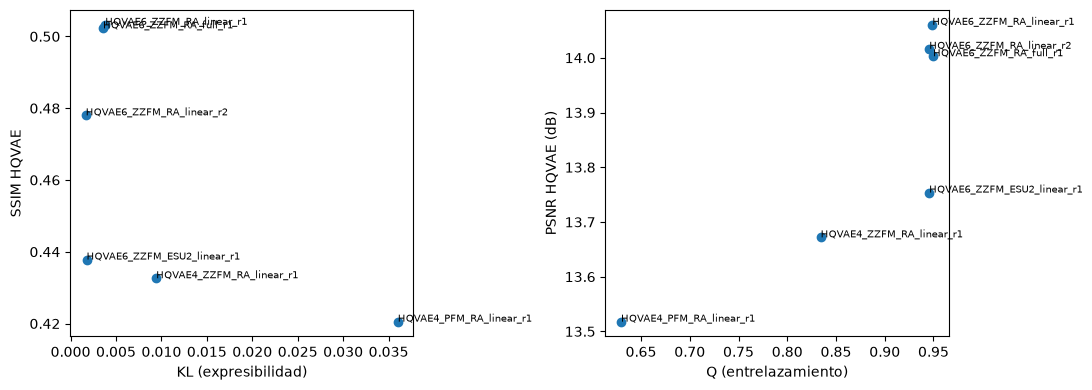

In [ ]:
# expresibilidad/entrelazamiento vs calidad de reconstrucción
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df['kl'], df['ssim_hqvae']); axes[0].set_xlabel('KL (expresibilidad)'); axes[0].set_ylabel('SSIM HQVAE')
axes[1].scatter(df['Q'], df['psnr_hqvae']); axes[1].set_xlabel('Q (entrelazamiento)'); axes[1].set_ylabel('PSNR HQVAE (dB)')
for i, t in enumerate(df['tag']):
    axes[0].annotate(t, (df['kl'][i], df['ssim_hqvae'][i]), fontsize=7)
    axes[1].annotate(t, (df['Q'][i], df['psnr_hqvae'][i]), fontsize=7)
plt.tight_layout(); plt.show()

## 5. Comparación de optimizadores

Mismo circuito, distintos optimizadores. `adam/adamw/sgd/rmsprop/lbfgs` entrenan end-to-end; `cobyla`/`spsa` refinan solo los pesos del ansatz cuántico sin gradiente (experimental, lento — descómentalos si quieres probarlos).

In [ ]:
opt_rows = []
for opt in ['adam', 'rmsprop', 'sgd', 'cobyla', 'spsa']:   # añade 'cobyla' o 'spsa' (lentos)
    c = hl.HQVAEConfig(n_qubits=6, feature_map='zz', ansatz='real_amplitudes',
                       ansatz_entanglement='linear', reps=1, latent_dim=8,
                       beta=0.5, epochs=15, optimizer=opt, seed=SEED)
    res = hl.run_config(c, loaders, device=DEVICE, results_dir=RESULTS_DIR, train_baseline=False)
    opt_rows.append(res['row'])

pd.DataFrame(opt_rows)[['optimizer', 'mse_hqvae', 'psnr_hqvae', 'ssim_hqvae']]

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE6_ZZFM_RA_linear_r1] entrenando HQVAE (adam)...
  epoch  1/15  train=441.39  val=295.28
  epoch  2/15  train=261.95  val=230.54
  epoch  3/15  train=226.72  val=210.95
  epoch  4/15  train=215.39  val=206.93
  epoch  5/15  train=211.52  val=202.91
  epoch  6/15  train=205.39  val=198.58
  epoch  7/15  train=198.48  val=192.72
  epoch  8/15  train=195.19  val=188.95
  epoch  9/15  train=188.35  val=183.99
  epoch 10/15  train=182.21  val=175.35
  epoch 11/15  train=172.19  val=164.68
  epoch 12/15  train=164.13  val=160.28
  epoch 13/15  train=157.78  val=153.58
  epoch 14/15  train=152.70  val=150.25
  epoch 15/15  train=147.79  val=147.25
[HQVAE6_ZZFM_RA_linear_r1] calculando descriptores de expresibilidad/entrelazamiento...


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE6_ZZFM_RA_linear_r1] HTML -> results\HQVAE6_ZZFM_RA_linear_r1.html
[HQVAE6_ZZFM_RA_linear_r1_rmsprop] entrenando HQVAE (rmsprop)...
  epoch  1/15  train=304.17  val=213.49
  epoch  2/15  train=218.94  val=209.90
  epoch  3/15  train=214.86  val=203.59
  epoch  4/15  train=212.81  val=208.94
  epoch  5/15  train=211.09  val=202.46
  epoch  6/15  train=209.07  val=203.45
  epoch  7/15  train=208.31  val=199.56
  epoch  8/15  train=207.41  val=199.68
  epoch  9/15  train=203.76  val=198.88
  epoch 10/15  train=202.85  val=195.65
  epoch 11/15  train=200.03  val=197.51
  epoch 12/15  train=196.00  val=190.07
  epoch 13/15  train=192.24  val=186.95
  epoch 14/15  train=189.40  val=180.19
  epoch 15/15  train=180.79  val=170.87
[HQVAE6_ZZFM_RA_linear_r1_rmsprop] calculando descriptores de expresibilidad/entrelazamiento...


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


...

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE6_ZZFM_RA_linear_r1_sgd] HTML -> results\HQVAE6_ZZFM_RA_linear_r1_sgd.html
[HQVAE6_ZZFM_RA_linear_r1_cobyla] entrenando HQVAE (cobyla)...
  [gradient-free] fase 1: warm-up end-to-end con Adam
  epoch  1/15  train=441.26  val=297.34
  epoch  2/15  train=261.59  val=229.29
  epoch  3/15  train=226.48  val=211.15
  epoch  4/15  train=215.62  val=205.79
  epoch  5/15  train=210.58  val=204.95
  epoch  6/15  train=203.97  val=197.43
  epoch  7/15  train=198.23  val=192.51
  epoch  8/15  train=193.40  val=188.85
  epoch  9/15  train=188.61  val=182.28
  epoch 10/15  train=180.55  val=175.58
  epoch 11/15  train=171.49  val=163.99
  epoch 12/15  train=161.67  val=162.12
  epoch 13/15  train=158.01  val=157.09
  epoch 14/15  train=152.77  val=150.25
  epoch 15/15  train=147.91  val=148.59
  [gradient-free] fase 2: refinado COBYLA de 12 pesos del ansatz
  [gradient-free] val loss tras refinado = 147.40
[HQVAE6_ZZFM_RA_linear_r1_cobyla] calculando descriptores de expresibilidad/entrelazami

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


[HQVAE6_ZZFM_RA_linear_r1_cobyla] HTML -> results\HQVAE6_ZZFM_RA_linear_r1_cobyla.html
[HQVAE6_ZZFM_RA_linear_r1_spsa] entrenando HQVAE (spsa)...
  [gradient-free] fase 1: warm-up end-to-end con Adam
  epoch  1/15  train=441.81  val=294.82
  epoch  2/15  train=260.57  val=227.31
  epoch  3/15  train=225.36  val=211.79
  epoch  4/15  train=215.72  val=207.37
  epoch  5/15  train=211.80  val=203.49
  epoch  6/15  train=207.12  val=199.81
  epoch  7/15  train=201.14  val=194.07
  epoch  8/15  train=195.60  val=189.76
  epoch  9/15  train=189.74  val=183.17
  epoch 10/15  train=181.96  val=176.65
  epoch 11/15  train=174.76  val=167.41
  epoch 12/15  train=165.78  val=161.59
  epoch 13/15  train=158.18  val=153.38
  epoch 14/15  train=152.33  val=149.22
  epoch 15/15  train=146.08  val=145.12
  [gradient-free] fase 2: refinado SPSA de 12 pesos del ansatz
  [gradient-free] val loss tras refinado = 144.85
[HQVAE6_ZZFM_RA_linear_r1_spsa] calculando descriptores de expresibilidad/entrelazamien

,optimizer,mse_hqvae,psnr_hqvae,ssim_hqvae
0,adam,0.042669,14.016813,0.497327
1,rmsprop,0.053165,12.924203,0.301593
2,sgd,0.067991,11.788118,0.163385
3,cobyla,0.042626,14.002224,0.493814
4,spsa,0.041471,14.144594,0.500205


## 6. Exportar el notebook completo a HTML (nbconvert)

Además de los HTML autocontenidos por run que ya se guardan en `results/`, puedes exportar todo el notebook ejecutado a un único HTML.

In [10]:
!jupyter nbconvert --to html test-hqvaetest_hqvae.ipynb

Failed to canonicalize script path
